In [8]:
import sys
import os 

sys.path.append(os.path.abspath(os.path.join('..')))

In [9]:
import torch
import torch.nn as nn
import torch.optim as optim
from pathlib import Path
import numpy as np
from src.models import GMSKAutoEncoder, GMSK_VAE
from src.loss import vae_loss_function
from torch.utils.data import DataLoader, TensorDataset

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Current device: {device}")

data_path = Path.cwd().parent / "Data"

# Load Data
X = torch.from_numpy(np.load(data_path / "X_noisy.npy")).float()  # Noisy signals
Y = torch.from_numpy(np.load(data_path / "Y_clean.npy")).float()  # Clean signals

Current device: cpu


In [10]:
# Setup model, loss & optimizer
AE_model = GMSKAutoEncoder().to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(AE_model.parameters(), lr=0.001)
num_epochs = 50

AE_model.summary()

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv1d-1             [-1, 16, 2048]             112
       BatchNorm1d-2             [-1, 16, 2048]              32
              ReLU-3             [-1, 16, 2048]               0
            Conv1d-4             [-1, 32, 2048]           1,568
       BatchNorm1d-5             [-1, 32, 2048]              64
              ReLU-6             [-1, 32, 2048]               0
         MaxPool1d-7             [-1, 32, 1024]               0
   ConvTranspose1d-8             [-1, 16, 2048]           1,040
       BatchNorm1d-9             [-1, 16, 2048]              32
             Tanh-10             [-1, 16, 2048]               0
           Conv1d-11              [-1, 8, 2048]             392
      BatchNorm1d-12              [-1, 8, 2048]              16
             Tanh-13              [-1, 8, 2048]               0
           Conv1d-14              [-1, 

In [11]:
# Define the path
save_path = Path.cwd().parent / "weights" / "AE_model.pth"

# Ensure the weights directory exists
save_path.parent.mkdir(parents=True, exist_ok=True)

if save_path.exists():
    load = input("Weight file exists. Do you want to retrain? (y/n):")
    if load == "n":
        print(f"--- Loading weights from {save_path} ---")
        # Load the state dictionary into the model
        AE_model.load_state_dict(torch.load(save_path, weights_only=True))
        AE_model.eval() # Set to evaluation mode
        skip_training = True
    else:
        print("--- Retraining ---")
        skip_training = False
else:
    skip_training = False

if not skip_training:
    AE_model.train() # Ensure model is in training mode
    
    for epoch in range(num_epochs):
        optimizer.zero_grad()
        outputs = AE_model(X)
        loss = criterion(outputs, Y)
        loss.backward()
        optimizer.step()
        
        if epoch % 10 == 0:
            print(f"Epoch {epoch}, Loss: {loss.item()}")

    # Save after the first training
    torch.save(AE_model.state_dict(), save_path)
    print(f"--- Training complete for deterministic auto-encoder. Model saved to {save_path} ---")

--- Loading weights from c:\Users\charl\OneDrive\Bureau\Cubesat-Radioastronomie\weights\AE_model.pth ---


In [12]:
VAE_model = GMSK_VAE().to(device)
optimizer = torch.optim.Adam(VAE_model.parameters(), lr = 1e-3)

dataset = TensorDataset(X, Y)
train_loader = DataLoader(dataset, batch_size = 32, shuffle = True)

In [ ]:
save_path = Path.cwd().parent / "weights" / "VAE_model.pth"

if save_path.exists():
    load = input("Weight file exists. Do you want to retrain? (y/n):")
    if load == "n":
        print(f"--- Loading weights from {save_path} ---")
        # Load the state dictionary into the model
        VAE_model.load_state_dict(torch.load(save_path, weights_only=True))
        VAE_model.eval() # Set to evaluation mode
        skip_training = True
    else:
        print("--- Retraining ---")
        skip_training = False
else:
    skip_training = False

if not skip_training:
    for epoch in range(num_epochs):
        VAE_model.train()
        total_loss = 0

        for i, (noisy, clean) in enumerate(train_loader):
            noisy, clean = noisy.to(device), clean.to(device)
            optimizer.zero_grad()

            #VAE return 3 things now
            recon_batch, mu, logvar = VAE_model(noisy)

            loss, mse, kld = vae_loss_function(recon_batch,clean, mu, logvar, beta = 1e-4)
    
            loss.backward()
            optimizer.step()

            total_loss +=loss.item()

        if epoch % 10 == 0:
            print(f"Epoch {epoch}, Loss: {loss.item()}")

    torch.save(AE_model.state_dict(), save_path)
    print(f"--- Training complete for deterministic auto-encoder. Model saved to {save_path} ---")

Epoch 0, Loss: 1.0055031776428223
Epoch 10, Loss: 0.509652853012085
Epoch 20, Loss: 0.5028551816940308
Epoch 30, Loss: 0.5011988878250122
Epoch 40, Loss: 0.5007500648498535
--- Training complete for deterministic auto-encoder. Model saved to c:\Users\charl\OneDrive\Bureau\Cubesat-Radioastronomie\weights\VAE_model.pth ---


In [29]:
from src.modulation import gmsk_demod
from src.test_gen import generate_test_signal

snr_range = np.arange(0, 19)  # SNRs from 0dB to 19dB
L = 16  # Samples per symbol
fc = 146e6  # Carrier frequency

bits, s_noisy, s_clean = generate_test_signal(2**10, 13, L, fc)
# 32kbit signal
s_noisy_norm = s_noisy / np.max(np.abs(s_noisy))

AE_model.eval()
VAE_model.eval()

input_tensor = torch.from_numpy(np.vstack((s_noisy.real, s_noisy.imag))).float().unsqueeze(0)
with torch.no_grad():
    AE_denoised_raw = AE_model(input_tensor).squeeze(0).numpy()
    VAE_denoised, mu, logvar = VAE_model(input_tensor)

AE_denoised = AE_denoised_raw[0, :] + 1j * AE_denoised_raw[1, :]

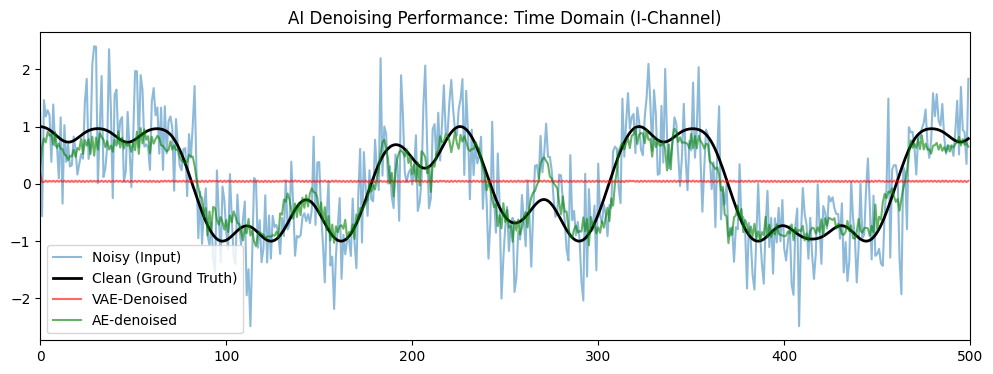

In [30]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))
plt.plot(s_noisy[:500], label='Noisy (Input)', alpha=0.5)
plt.plot(s_clean[:500], label='Clean (Ground Truth)', color='black', lw=2)
plt.plot(VAE_denoised[0, 0, :500], label='VAE-Denoised', color='red', alpha = 0.6)
plt.plot(AE_denoised[:500], label='AE-denoised', color = "green", alpha = 0.6 )
plt.xlim(0, 500)
plt.title("AI Denoising Performance: Time Domain (I-Channel)")
plt.legend()
plt.show()

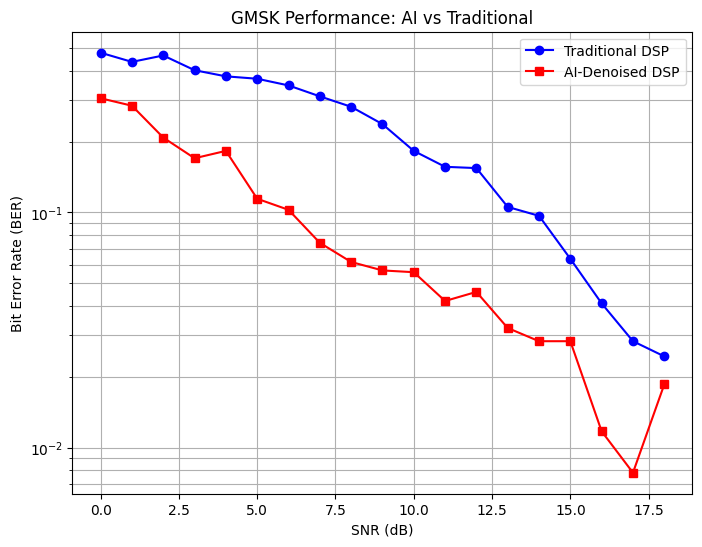

In [ ]:


ber_traditional = []
ber_ai_assisted = []

model.eval()

for snr in snr_range:
    # 1. Generate test data for this specific SNR
    # (Assuming you have a helper to generate bits and noisy signals)
    bits, s_noisy, s_clean = generate_test_signal(1024, snr, L, fc)
    
    # --- Traditional Path ---
    bits_trad = gmsk_demod(s_noisy, L)
    err_trad = np.sum(bits != bits_trad) / len(bits)
    ber_traditional.append(err_trad)
    
    # --- AI Path ---
    # Prepare for model: (1, 2, Length)
    input_tensor = torch.from_numpy(np.vstack((s_noisy.real, s_noisy.imag))).float().unsqueeze(0)
    with torch.no_grad():
        denoised_iq_raw = model(input_tensor).squeeze(0).numpy()
    
    # Reconstruct complex signal from AI output
    s_denoised = denoised_iq_raw[0, :] + 1j * denoised_iq_raw[1, :]
    
    bits_ai = gmsk_demod(s_denoised, L)
    err_ai = np.sum(bits != bits_ai) / len(bits)
    ber_ai_assisted.append(err_ai)

# Plotting the Waterfall Curve
plt.figure(figsize=(8, 6))
plt.semilogy(snr_range, ber_traditional, 'b-o', label='Traditional DSP')
plt.semilogy(snr_range, ber_ai_assisted, 'r-s', label='AI-Denoised DSP')
plt.grid(True, which='both')
plt.xlabel('SNR (dB)')
plt.ylabel('Bit Error Rate (BER)')
plt.title('GMSK Performance: AI vs Traditional')
plt.legend()
plt.show()

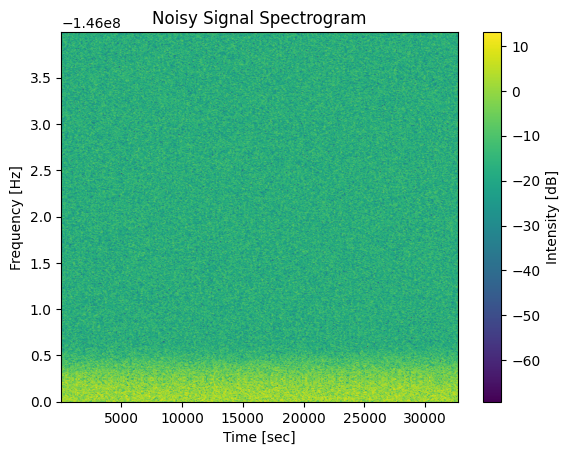

In [ ]:
# Plot spectrogram for noisy signal
from src.spectra import plot_spectrogram

plot_spectrogram(s_noisy, L, fc, title="Noisy Signal Spectrogram")

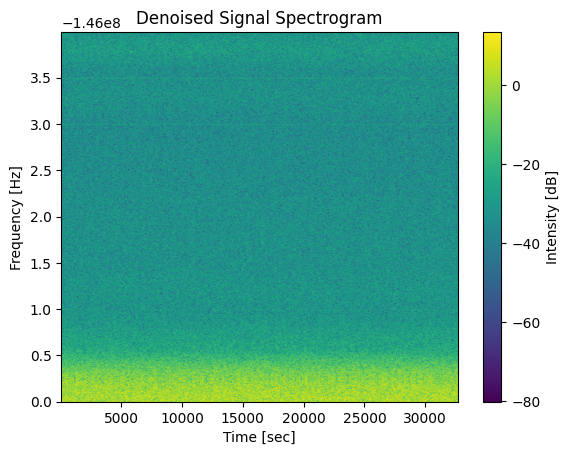

In [ ]:
# Plot spectrogram for denoised signal
plot_spectrogram(denoised_iq, L, fc, title="Denoised Signal Spectrogram")

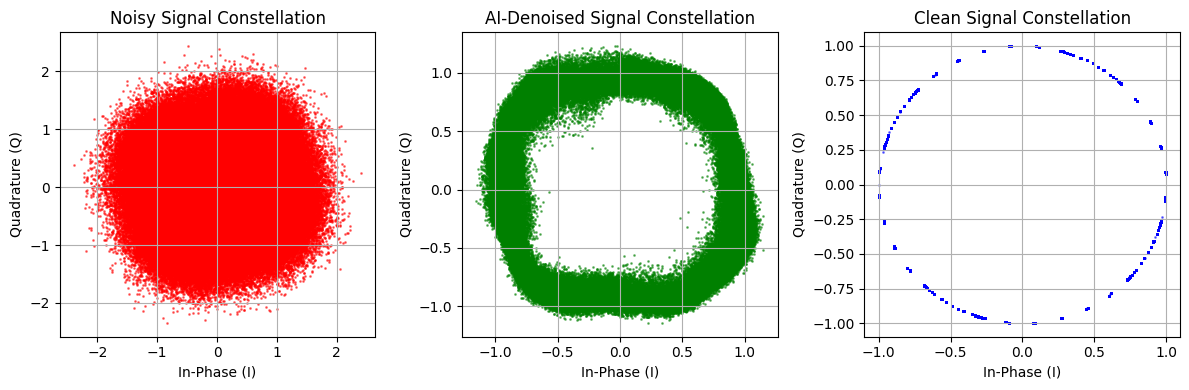

In [ ]:
i_noisy = s_noisy.real
q_noisy = s_noisy.imag

i_clean = s_clean.real
q_clean = s_clean.imag

i_denoised = denoised_iq.real
q_denoised = denoised_iq.imag

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(12, 4))

ax1.scatter(i_noisy, q_noisy, s=1, alpha=0.5, color = 'r')
ax1.set_title('Noisy Signal Constellation')
ax1.set_xlabel('In-Phase (I)')
ax1.set_ylabel('Quadrature (Q)')
ax1.grid(True)

ax2.scatter(i_denoised, q_denoised, s=1, alpha=0.5, color = 'g')
ax2.set_title('AI-Denoised Signal Constellation')
ax2.set_xlabel('In-Phase (I)')
ax2.set_ylabel('Quadrature (Q)')
ax2.grid(True)

ax3.scatter(i_clean, q_clean, s=1, alpha=0.5, color = 'b')
ax3.set_title('Clean Signal Constellation')
ax3.set_xlabel('In-Phase (I)')
ax3.set_ylabel('Quadrature (Q)')
ax3.grid(True)

plt.tight_layout()
plt.show()